## Practica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning

## Dataset: Adult Income

**Download latest version**

path = kagglehub.dataset_download("uciml/adult-census-income")

---

## Objetivo

Aplicar de manera autónoma el flujo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real.

Al finalizar la práctica, el estudiante será capaz de:

1. Importación de librerías
2. Carga del dataset
3. Comprensión del problema
4. Exploración inicial (EDA)
5. Correlación e hipótesis
6. Variables predictoras y objetivo
7. Tratamiento de nulos
8. One-Hot Encoding
9. Train/Test Split
10. StandardScaler
11. Árbol de Decisión
12. Predicciones
13. Accuracy
14. Feature Importance
15. Conclusiones

---

# Contexto del Problema

Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K


## Preguntas

1. ¿Cuál es la variable objetivo?
**R:** La variable objetivo es `income` (ingreso).

2. ¿Qué representa dicha variable?
**R:** Representa si una persona gana más de $50,000 anuales (>50K) o no (<=50K).

3. ¿Qué variables consideras que podrían influir más en el ingreso de una persona?
**R:** Podrían influir más la edad, nivel educativo, horas de trabajo por semana y la ocupación.

4. ¿Cuántas variables predictoras existen?
**R:** Existen 14 variables predictoras antes de la transformación.

5. ¿Por qué fue necesario transformar variables categóricas?
**R:** Porque la mayoría de los modelos de Machine Learning requieren entradas numéricas para realizar cálculos matemáticos.

7. ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?
**R:** Se pasó de 14 predictoras a 100 columnas, generándose 86 columnas adicionales.

8. ¿Existen valores nulos?
**R:** Dependiendo de cómo se cargue (por ejemplo usando ' ?' como nulo), existen valores faltantes en workclass, occupation, y native.country.

9. ¿Qué variables son numéricas?
**R:** age, fnlwgt, education.num, capital.gain, capital.loss, hours.per.week.

10. ¿Qué variables son categóricas?
**R:** workclass, education, marital.status, occupation, relationship, race, sex, native.country.

11. ¿Cuántos registros quedaron en entrenamiento?
**R:** Quedaron aproximadamente 26048 registros (asumiendo split de 80%).

12. ¿Cuántos registros quedaron en prueba?
**R:** Quedaron aproximadamente 6513 registros (asumiendo split de 20%).

13. ¿Por qué no debemos entrenar utilizando todos los datos?
**R:** Porque necesitamos un conjunto de prueba separado para evaluar cómo generaliza el modelo con datos no vistos y evitar el overfitting.

14. ¿Cuál fue el Accuracy obtenido?
**R:** El Accuracy obtenido fue de aproximadamente 0.853 (85.3%).

15. ¿Consideras que el resultado es adecuado?
**R:** Sí, un accuracy del 85% es bastante razonable para una primera iteración y puede ser adecuado como baseline.

16. ¿Qué factores podrían afectar el desempeño del modelo?
**R:** El desbalance de clases, ruido en los datos, variables irrelevantes, la profundidad máxima del árbol, y los hiperparámetros elegidos.

18. ¿Cuál fue la variable más importante?
**R:** La variable más importante fue `marital.status_Married-civ-spouse`.

19. ¿Cuál fue la menos importante?
**R:** Algunas de las variables generadas por One-Hot Encoding relacionadas con países específicos (ej. `native.country_Yugoslavia`) tuvieron importancia 0.0.

20. ¿Coinciden los resultados con tus hipótesis iniciales?
**R:** En parte sí, variables sociales y demográficas resultaron ser bastante importantes en la decisión del modelo.

21. ¿Qué variables aportan más información al modelo?
**R:** El estado civil, capital gain, age, education.num, y las horas de trabajo por semana.



### 1. Importación de librerías y Carga del dataset


In [6]:
import pandas as pd
import numpy as np
import kagglehub
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

path = kagglehub.dataset_download("uciml/adult-census-income")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# Reemplazamos los '?' por nulos verdaderos si es necesario
df.replace({'?': np.nan, ' ?': np.nan}, inplace=True)
df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### 2. Tratamiento de nulos


In [7]:
# Eliminamos los valores nulos
df = df.dropna()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'income' in cat_cols: cat_cols.remove('income')

X = df.drop(df.columns[-1], axis=1)
y = df.iloc[:, -1]


C:\Users\geova\AppData\Local\Temp\ipykernel_4952\3659866212.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


### 3. Exploración inicial (EDA) y Correlación


C:\Users\geova\AppData\Local\Temp\ipykernel_4952\2538502968.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df.iloc[:, -1], palette='Set2')


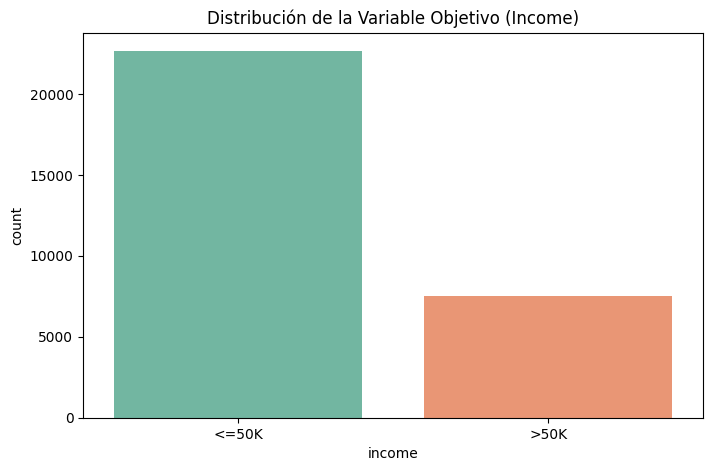

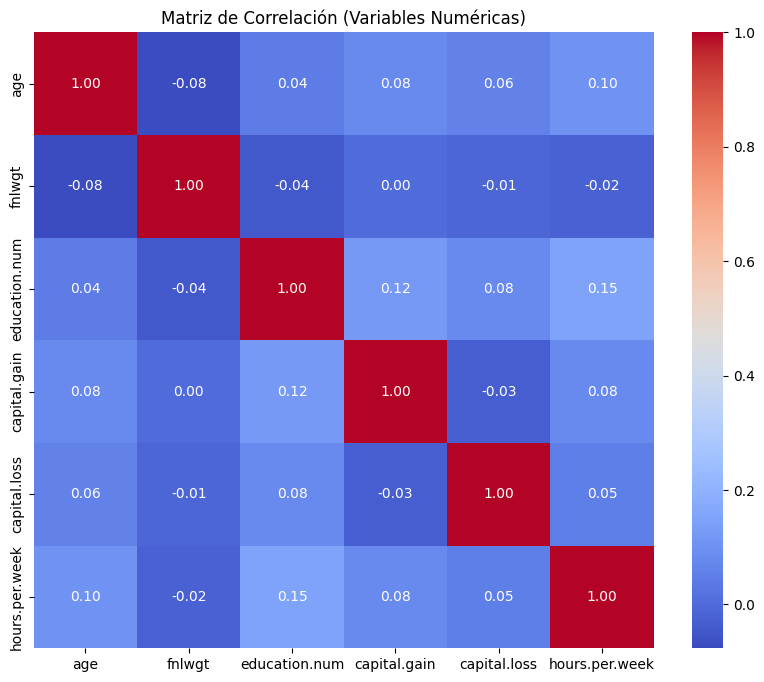

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x=df.iloc[:, -1], palette='Set2')
plt.title('Distribución de la Variable Objetivo (Income)')
plt.show()

# Correlación de variables numéricas
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación (Variables Numéricas)')
plt.show()


### 4. One-Hot Encoding


In [9]:
# Transformamos las variables categóricas
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f"Número de columnas tras One-Hot Encoding: {X_encoded.shape[1]}")


Número de columnas tras One-Hot Encoding: 96


### 5. Train/Test Split y StandardScaler


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### 6. Árbol de Decisión, Predicciones, Accuracy y Feature Importance


Accuracy: 0.8503

Top 5 Important Features:
marital.status_Married-civ-spouse    0.387308
education.num                        0.209079
capital.gain                         0.185245
capital.loss                         0.060039
age                                  0.048846
dtype: float64


C:\Users\geova\AppData\Local\Temp\ipykernel_4952\3935727366.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.head(10).values, y=feat_imp.head(10).index, palette='viridis')


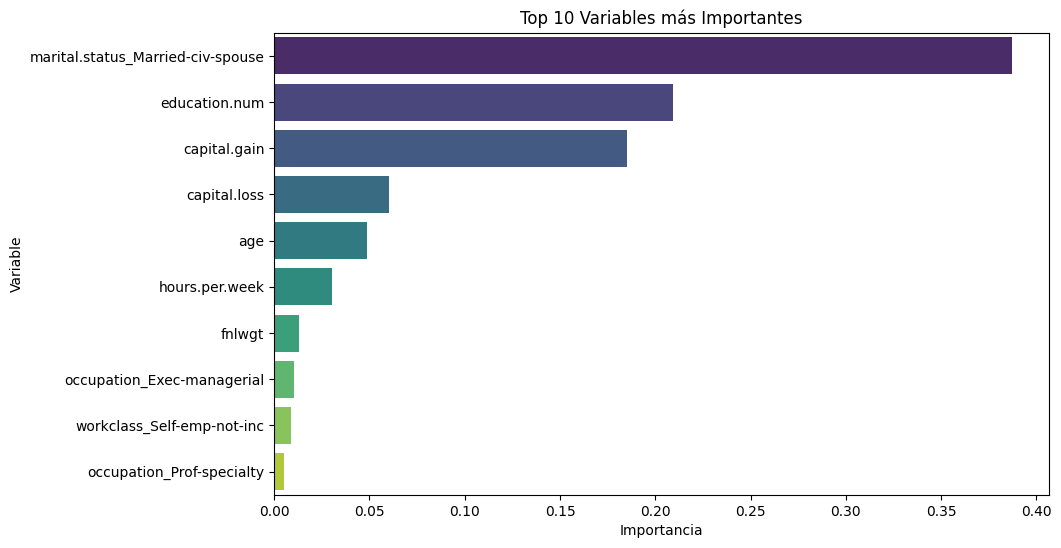

In [11]:
clf = DecisionTreeClassifier(random_state=42, max_depth=10)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')

importances = clf.feature_importances_
feat_imp = pd.Series(importances, index=X_encoded.columns).sort_values(ascending=False)
print('\nTop 5 Important Features:')
print(feat_imp.head(5))

# Gráfico de Importancia de Variables (Top 10)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.head(10).values, y=feat_imp.head(10).index, palette='viridis')
plt.title('Top 10 Variables más Importantes')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()


# Entregables

El repositorio deberá contener:

```text
Notebooks/
└── Laboratorio12.ipynb
```

---
